### Imports

In [1]:
import scanpy as sc
import scanpy.external as sce
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from pathlib import Path
import warnings
import mygene
from scipy.stats import median_abs_deviation
import re
import anndata as ad
import scrublet as scr


In [2]:
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", message="ChainedAssignmentError")

In [3]:
base_dir = Path().resolve().parent
base_dir

WindowsPath('C:/Users/mills/Desktop/Angione Lab')

In [4]:
# df = pd.read_csv("C:\\Users\\mills\\Desktop\\Angione Lab\\OC\\HumanOvarianCancerPatient2Slice2_cell_by_gene.csv", index_col=0)
# adata = ad.AnnData(df)
# adata
# gene_meta = pd.read_csv("C:\\Users\\mills\\Desktop\\Angione Lab\\OC\\HumanOvarianCancerPatient2Slice2_cell_metadata.csv", index_col=0)

### Load data

In [5]:
# Load gene expression and metadata
gene_expr_path = r"C:\Users\mills\Desktop\Angione Lab\OC\HumanOvarianCancerPatient2Slice2_cell_by_gene.csv"
metadata_path = r"C:\Users\mills\Desktop\Angione Lab\OC\HumanOvarianCancerPatient2Slice2_cell_metadata.csv"

df = pd.read_csv(gene_expr_path, index_col=0)
gene_meta = pd.read_csv(metadata_path, index_col=0)

### Create Anndata object

In [6]:
adata = sc.AnnData(df)
adata.obs = gene_meta.iloc[:adata.n_obs].copy()  

# keep gene expression row indices as obs_names
adata.obs_names = df.index.astype(str)

In [7]:
print("AnnData shape:", adata.shape)
print("First 5 rows of obs:")
print(adata.obs.head())

AnnData shape: (71381, 550)
First 5 rows of obs:
       fov       volume      center_x     center_y         min_x  \
cell                                                               
0     1413  2164.001882  10145.793273  5611.686548  10135.374848   
1     1413   799.191933   9975.309392  5626.726410   9969.399281   
2     1413  1499.366735  10129.182535  5630.601069  10120.147947   
3     1413  1476.039756  10112.691788  5635.037877  10106.215328   
4     1413  1076.872046  10151.573577  5634.673399  10146.395020   

             max_x        min_y        max_y  
cell                                          
0     10156.211698  5602.912342  5620.460755  
1      9981.219504  5621.396968  5632.055852  
2     10138.217123  5623.778992  5637.423145  
3     10119.168248  5626.804584  5643.271170  
4     10156.752135  5627.678259  5641.668539  


In [9]:
adata

AnnData object with n_obs × n_vars = 71381 × 550
    obs: 'fov', 'volume', 'center_x', 'center_y', 'min_x', 'max_x', 'min_y', 'max_y'

In [10]:
adata_before = adata.copy()

### Check for Mitochondrial genes

In [11]:
print("any var names starting with 'MT-':", adata.var_names.str.startswith("MT-").sum())
print("any var names starting with 'mt-':", adata.var_names.str.startswith("mt-").sum())
# if gene symbols are in a separate column, show that column (common names: 'gene_ids' 'gene_symbols' or 'features')
print(adata.var.columns)
for col in adata.var.columns:
    if adata.var[col].dtype == object:
        s = adata.var[col].astype(str).str.startswith("MT-").sum()
        if s>0:
            print(f"column {col} has {s} MT- entries")

any var names starting with 'MT-': 0
any var names starting with 'mt-': 0
Index([], dtype='object')


In [12]:
# Show the gene names
print(adata.var_names[:20])

Index(['PDK4', 'CCL26', 'CX3CL1', 'CD4', 'SNAI2', 'TNFRSF17', 'ICAM3', 'TBX21',
       'FAP', 'NFKB2', 'LAG3', 'TGFBR3', 'MMP11', 'XBP1', 'IL2RB', 'GZMH',
       'GZMB', 'NFKBIA', 'MMP2', 'CCL22'],
      dtype='object')


In [13]:
# Quick check: any Ensembl-like names?
ensembl_like = [g for g in adata.var_names if re.match(r'ENSG\d{11}', g)]
print("Ensembl-like genes:", ensembl_like)

Ensembl-like genes: []


In [14]:
# Mitochondrial genes
adata.var["mt"] = adata.var_names.str.upper().str.startswith("MT-")
print("Number of mitochondrial genes:", adata.var["mt"].sum())

# Ribosomal genes (RPS / RPL)
adata.var["ribo"] = adata.var_names.str.upper().str.startswith(("RPS", "RPL"))
print("Number of ribosomal genes:", adata.var["ribo"].sum())

# Hemoglobin genes
adata.var["hb"] = adata.var_names.str.upper().str.match(r"HB[ABDEG]?")
print("Number of hemoglobin genes:", adata.var["hb"].sum())

# Inspect the annotation table
adata.var.head(10)


Number of mitochondrial genes: 0
Number of ribosomal genes: 0
Number of hemoglobin genes: 0


,mt,ribo,hb
PDK4,False,False,False
CCL26,False,False,False
CX3CL1,False,False,False
CD4,False,False,False
SNAI2,False,False,False
TNFRSF17,False,False,False
ICAM3,False,False,False
TBX21,False,False,False
FAP,False,False,False
NFKB2,False,False,False


In [15]:
sc.pp.calculate_qc_metrics(adata, inplace=True, log1p=True)

In [16]:
adata.obs[["n_genes_by_counts", "total_counts"]].describe()

,n_genes_by_counts,total_counts
count,71381.000000,71381.000000
mean,103.860229,316.603116
std,48.766867,245.945436
min,0.000000,0.000000
25%,72.000000,145.000000
50%,107.000000,270.000000
75%,137.000000,430.000000
max,326.000000,2814.000000


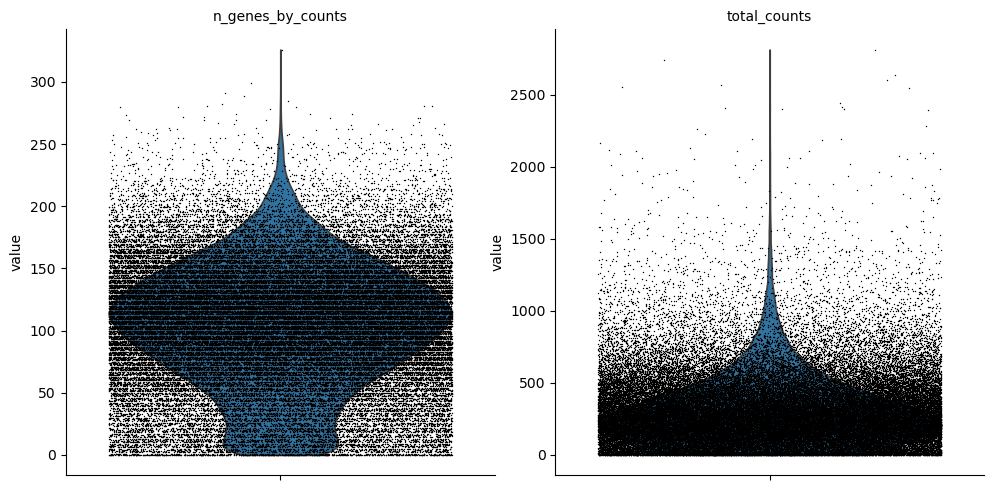

In [17]:
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts"],
    jitter=0.4,
    multi_panel=True,
)

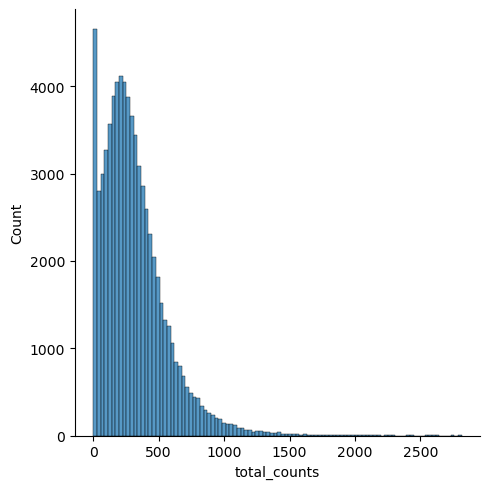

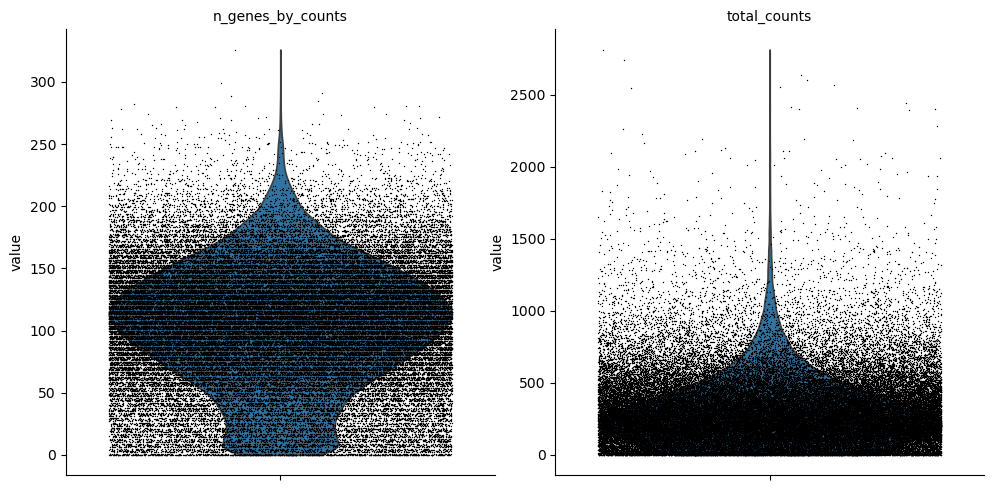

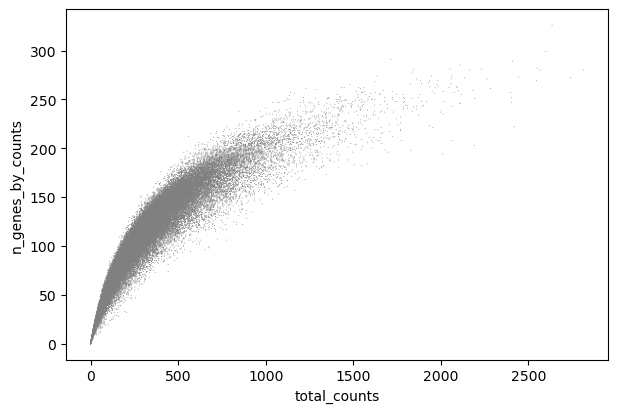

In [18]:
# Distribution of counts per cell
p1 = sns.displot(adata.obs["total_counts"], bins=100, kde=False)

# Violin plots for QC metrics
p2 = sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts"],
    jitter=0.4,
    multi_panel=True
)

# Scatter plot of counts vs genes detected
p3 = sc.pl.scatter(
    adata,
    x="total_counts",
    y="n_genes_by_counts"
)

In [19]:
print("Dataset shape BEFORE QC:")
print(adata.shape)

metrics = [
    "n_genes_by_counts",
    "total_counts",
    "pct_counts_mt",             # may be missing in tissue slices
    "pct_counts_in_top_20_genes" # may be missing
]

for m in metrics:
    print("\n==============================")
    print("Metric:", m)
    print("==============================")

    if m not in adata.obs.columns:
        print(f"Metric '{m}' not found in adata.obs. Skipping...")
        continue

    vals = adata.obs[m].values

    print("Min:", np.min(vals))
    print("Max:", np.max(vals))
    print("Mean:", np.mean(vals))
    print("Median:", np.median(vals))

    print("\nQuantiles:")
    for q in [0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]:
        print(f"{int(q*100)}% :", np.quantile(vals, q))

    print("\nCells below common thresholds:")
    
    if m == "n_genes_by_counts":
        for t in [100, 200, 250, 500]:
            print(f"<{t} :", np.sum(vals < t))

    elif m == "pct_counts_mt":
        for t in [5, 10, 20, 30]:
            print(f">{t}% :", np.sum(vals > t))

    elif m == "pct_counts_in_top_20_genes":
        for t in [40, 50, 60]:
            print(f">{t}% :", np.sum(vals > t))

Dataset shape BEFORE QC:
(71381, 550)

Metric: n_genes_by_counts
Min: 0
Max: 326
Mean: 103.8602289124557
Median: 107.0

Quantiles:
1% : 1.0
5% : 15.0
10% : 34.0
25% : 72.0
50% : 107.0
75% : 137.0
90% : 164.0
95% : 181.0
99% : 214.0

Cells below common thresholds:
<100 : 31575
<200 : 69897
<250 : 71276
<500 : 71381

Metric: total_counts
Min: 0.0
Max: 2814.0
Mean: 316.6031156750396
Median: 270.0

Quantiles:
1% : 1.0
5% : 19.0
10% : 53.0
25% : 145.0
50% : 270.0
75% : 430.0
90% : 620.0
95% : 773.0
99% : 1151.0

Cells below common thresholds:

Metric: pct_counts_mt
Metric 'pct_counts_mt' not found in adata.obs. Skipping...

Metric: pct_counts_in_top_20_genes
Metric 'pct_counts_in_top_20_genes' not found in adata.obs. Skipping...


### Quality control

In [20]:
# Quality control adapted for Vizgen / low gene spatial dataset
print(f"Total number of cells BEFORE QC: {adata.n_obs}")

# Remove completely empty / extremely weak cells
sc.pp.filter_cells(adata, min_genes=40)

# Remove extremely rare genes
sc.pp.filter_genes(adata, min_cells=20)


# Outlier detection (relaxed for spatial data)
def is_outlier(adata, metric: str, nmads: int):
    M = adata.obs[metric]
    outlier = (
        (M < np.median(M) - nmads * median_abs_deviation(M)) |
        (M > np.median(M) + nmads * median_abs_deviation(M))
    )
    return outlier


# Detect extreme outliers only
adata.obs["outlier"] = (
    is_outlier(adata, "log1p_total_counts", 6) |
    is_outlier(adata, "log1p_n_genes_by_counts", 6)
)

print("Outlier counts:")
print(adata.obs["outlier"].value_counts())

Total number of cells BEFORE QC: 71381
Outlier counts:
outlier
False    63072
Name: count, dtype: int64


### Remove outliers

In [21]:
# Remove outliers
adata = adata[~adata.obs["outlier"]].copy()

print(f"Total number of cells AFTER QC: {adata.n_obs}")

Total number of cells AFTER QC: 63072


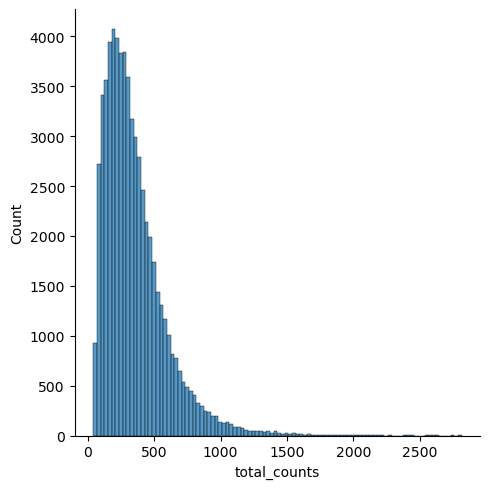

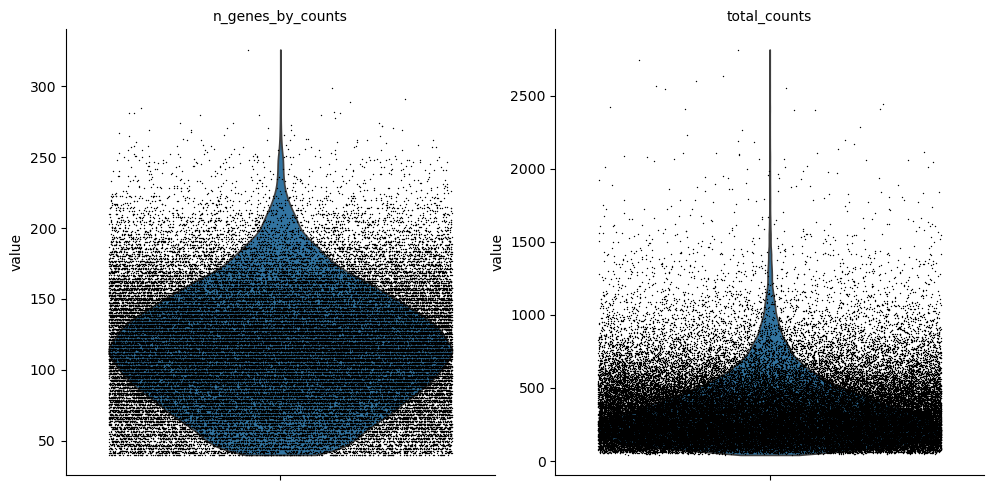

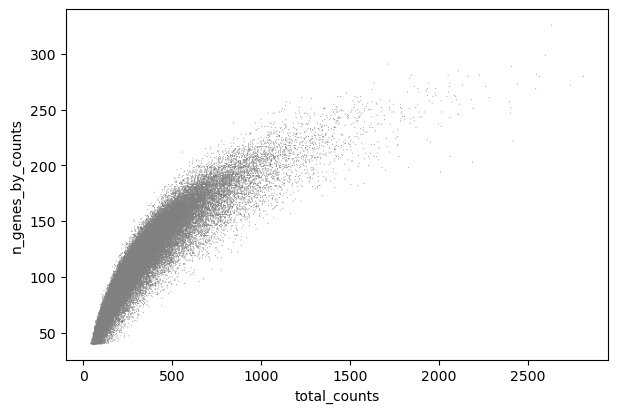

In [22]:
# 1️ Distribution of total counts per cell
p1 = sns.displot(adata.obs["total_counts"], bins=100, kde=False)

# 2️ Violin plots of QC metrics
p2 = sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts"],
    jitter=0.4,
    multi_panel=True
)

# 3️ Scatter plot: total counts vs genes detected
p3 = sc.pl.scatter(
    adata,
    x="total_counts",
    y="n_genes_by_counts"
)

In [23]:
X = adata.X

print("Dataset shape:", X.shape)

print("\nCounts per cell")
cell_counts = np.sum(X, axis=1)
print("Min:", cell_counts.min())
print("Median:", np.median(cell_counts))
print("Mean:", cell_counts.mean())
print("Max:", cell_counts.max())

print("\nGenes per cell")
genes_per_cell = np.sum(X > 0, axis=1)
print("Min:", genes_per_cell.min())
print("Median:", np.median(genes_per_cell))
print("Mean:", genes_per_cell.mean())
print("Max:", genes_per_cell.max())

print("\nCells per gene")
cells_per_gene = np.sum(X > 0, axis=0)
print("Min:", cells_per_gene.min())
print("Median:", np.median(cells_per_gene))
print("Mean:", cells_per_gene.mean())
print("Max:", cells_per_gene.max())

Dataset shape: (63072, 550)

Counts per cell
Min: 42.0
Median: 301.0
Mean: 354.5622938863521
Max: 2814.0

Genes per cell
Min: 40
Median: 114.0
Mean: 115.08051116184677
Max: 326

Cells per gene
Min: 668
Median: 5689.0
Mean: 13197.014545454545
Max: 61440


### Removal of blank genes

In [24]:
blank_genes = adata.var_names.str.contains("blank", case=False)
print("Number of blank/control genes:", blank_genes.sum())
print("Blank genes:", adata.var_names[blank_genes].tolist())

Number of blank/control genes: 50
Blank genes: ['Blank-1', 'Blank-2', 'Blank-3', 'Blank-4', 'Blank-5', 'Blank-6', 'Blank-7', 'Blank-10', 'Blank-11', 'Blank-12', 'Blank-15', 'Blank-16', 'Blank-18', 'Blank-19', 'Blank-21', 'Blank-22', 'Blank-23', 'Blank-25', 'Blank-26', 'Blank-27', 'Blank-28', 'Blank-30', 'Blank-33', 'Blank-35', 'Blank-36', 'Blank-37', 'Blank-38', 'Blank-39', 'Blank-40', 'Blank-41', 'Blank-42', 'Blank-43', 'Blank-44', 'Blank-45', 'Blank-47', 'Blank-48', 'Blank-49', 'Blank-50', 'Blank-8', 'Blank-9', 'Blank-13', 'Blank-14', 'Blank-20', 'Blank-31', 'Blank-34', 'Blank-17', 'Blank-29', 'Blank-32', 'Blank-46', 'Blank-24']


In [25]:
print(f"Dataset shape after removing blank genes: {adata.shape}")

Dataset shape after removing blank genes: (63072, 550)


In [26]:
adata = adata[:, ~blank_genes].copy()

In [27]:
adata

AnnData object with n_obs × n_vars = 63072 × 500
    obs: 'fov', 'volume', 'center_x', 'center_y', 'min_x', 'max_x', 'min_y', 'max_y', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'n_genes', 'outlier'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'

In [28]:
counts_matrix = adata.X
scrub = scr.Scrublet(counts_matrix, expected_doublet_rate=0.04)
doublet_scores, predicted_doublets = scrub.scrub_doublets()
adata.obs['doublet_score'] = doublet_scores
adata.obs['predicted_doublet'] = predicted_doublets

Preprocessing...
Simulating doublets...
Embedding transcriptomes using PCA...
Calculating doublet scores...
Automatically set threshold at doublet score = 0.77
Detected doublet rate = 0.0%
Estimated detectable doublet fraction = 1.4%
Overall doublet rate:
	Expected   = 4.0%
	Estimated  = 0.3%
Elapsed time: 154.6 seconds


In [29]:
adata.obs[['doublet_score', 'predicted_doublet']].head()

,doublet_score,predicted_doublet
cell,,
3,0.005097,False
8,0.062057,False
9,0.020199,False
11,0.048061,False
12,0.011221,False


### Generate Final Transcriptomics Data for 150 HVG

In [30]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

In [31]:
sc.pp.highly_variable_genes(
    adata,
    n_top_genes=150,
    flavor="seurat_v3",
    subset=False
)

In [32]:
print(adata.var[['means', 'variances', 'variances_norm']].describe())

            means   variances  variances_norm
count  500.000000  500.000000      500.000000
mean     0.903708    1.892895        1.008330
std      1.036176    1.590340        0.126526
min      0.039201    0.128340        0.624626
25%      0.155658    0.521675        0.953411
50%      0.396452    1.303327        0.982236
75%      1.318996    3.169402        1.028864
max      6.082843   10.225884        2.361984


In [33]:
print("Highly Variable Genes selected:")
print(adata.var['highly_variable'].value_counts())

Highly Variable Genes selected:
highly_variable
False    350
True     150
Name: count, dtype: int64


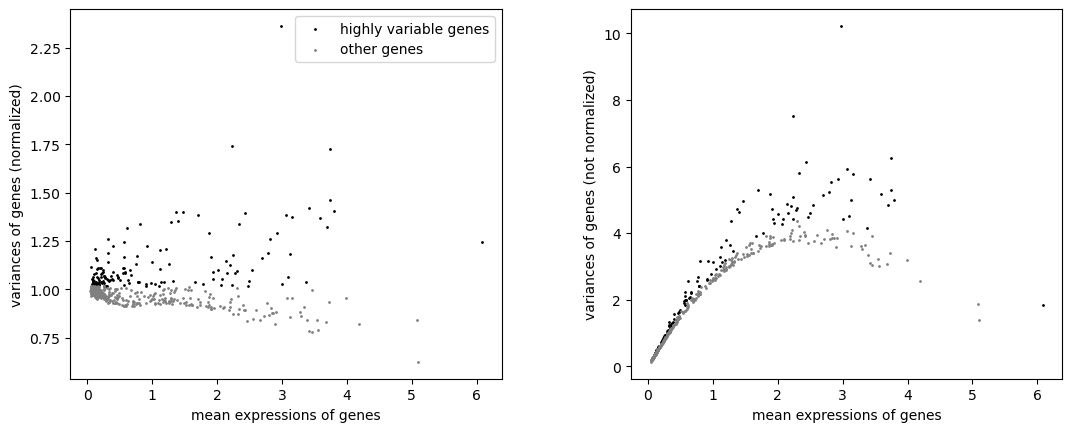

In [34]:
sc.pl.highly_variable_genes(adata)

In [35]:
adata_hvg = adata[:, adata.var['highly_variable']].copy()

In [36]:
sc.pp.scale(adata_hvg, max_value=10)

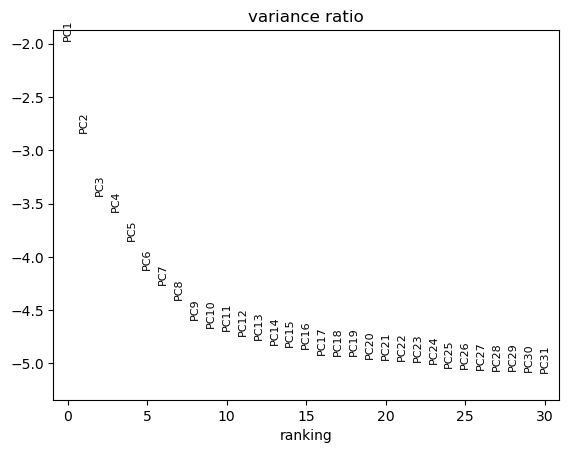

In [37]:
sc.tl.pca(adata_hvg, svd_solver='arpack')
sc.pl.pca_variance_ratio(adata_hvg, log=True)

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

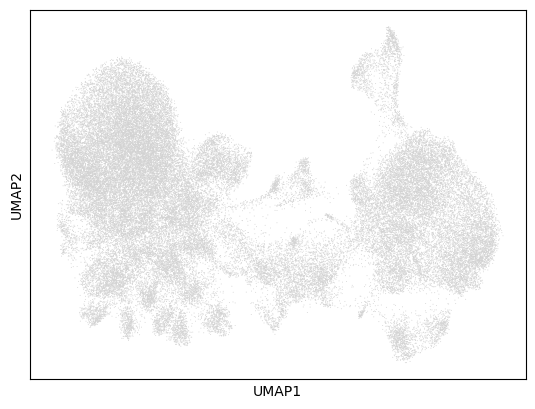

In [38]:
sc.pp.neighbors(adata_hvg, n_neighbors=15, n_pcs=30)
sc.tl.umap(adata_hvg)
sc.pl.umap(adata_hvg)

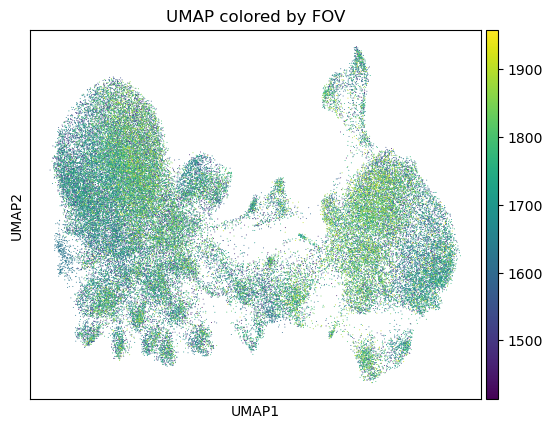

In [39]:
sc.pl.umap(adata_hvg, color='fov', title='UMAP colored by FOV', palette='tab10')

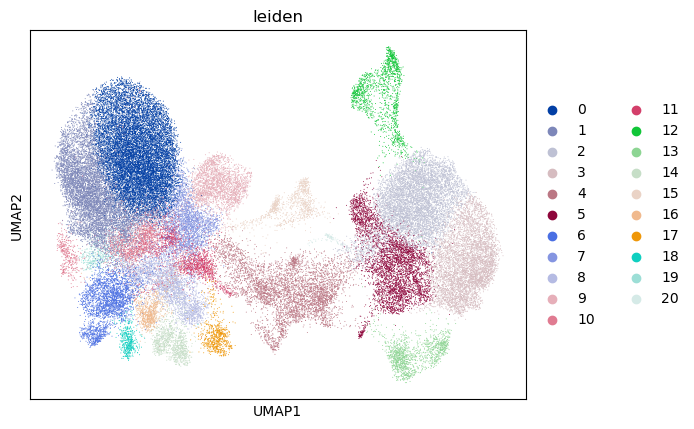

In [40]:
sc.tl.leiden(adata_hvg, resolution=0.5)  # or tune resolution
sc.pl.umap(adata_hvg, color='leiden')

In [41]:
adata_hvg.write(r"C:\Users\mills\Desktop\Angione Lab\OC\OC_adata_hvg.h5ad")